<a href="https://colab.research.google.com/github/yasseen116/Software-Defect-predection-Project/blob/main/DS_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [508]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("jm1.csv")
df.head()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1.0,1.0,1.0,1.0,1.0,True
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17.0,36.0,112.0,86.0,13.0,True
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17.0,135.0,329.0,271.0,5.0,True
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11.0,16.0,76.0,50.0,7.0,True


In [509]:
df.shape

(13204, 22)

In [510]:
# Basic description of Dataset
df.describe(include='all')

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
count,13204.000000,13204.000000,13204.000000,13204.000000,13204.000000,13204.000000,13204.000000,13204.000000,13204.000000,1.320400e+04,...,13204.000000,13204.000000,13204.000000,13204.000000,13204.000000,13204.000000,13204.000000,13204.000000,13204.000000,13204
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11101
mean,39.677530,6.020251,3.213678,3.817510,108.864836,633.893630,0.144374,13.858346,28.757208,3.365699e+04,...,25.099212,2.595880,4.432445,0.352242,11.022887,16.154287,64.777658,44.202984,10.669676,NaN
std,71.899364,12.194974,6.466248,8.478263,234.809111,1804.952017,0.165304,18.445102,32.502396,4.018395e+05,...,55.689103,8.693227,9.701587,1.808668,9.537749,24.918154,142.727488,94.311322,21.289988,NaN
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN
25%,10.000000,1.000000,1.000000,1.000000,14.000000,49.830000,0.040000,3.000000,12.270000,1.594500e+02,...,3.000000,0.000000,0.000000,0.000000,5.000000,4.000000,8.000000,6.000000,1.000000,NaN
50%,22.000000,3.000000,1.000000,2.000000,47.000000,206.580000,0.080000,8.895000,21.515000,1.877330e+03,...,12.000000,0.000000,2.000000,0.000000,10.000000,11.000000,28.000000,19.000000,5.000000,NaN
75%,43.000000,6.000000,3.000000,4.000000,115.000000,593.487500,0.180000,18.240000,35.970000,1.049259e+04,...,27.000000,1.000000,5.000000,0.000000,15.000000,20.000000,69.000000,46.000000,11.000000,NaN


In [511]:
# 3. Rename columns to make them easier to understand

df = df.rename(columns={
    "loc": "lines_of_code",
    "v(g)": "cyclomatic_complexity",
    "ev(g)": "essential_complexity",
    "iv(g)": "design_complexity",
    "n": "halstead_length",
    "v": "halstead_volume",
    "l": "halstead_level",
    "d": "halstead_difficulty",
    "i": "halstead_intelligence",
    "e": "halstead_effort",
    "b": "halstead_bugs",
    "t": "halstead_time",
    "lOCode": "code_lines",
    "lOComment": "comment_lines",
    "lOBlank": "blank_lines",
    "locCodeAndComment": "code_comment_lines",
    "uniq_Op": "unique_operators",
    "uniq_Opnd": "unique_operands",
    "total_Op": "total_operators",
    "total_Opnd": "total_operands",
    "branchCount": "branch_count",
    "defects": "defect"
})

df.head()

,lines_of_code,cyclomatic_complexity,essential_complexity,design_complexity,halstead_length,halstead_volume,halstead_level,halstead_difficulty,halstead_intelligence,halstead_effort,...,code_lines,comment_lines,blank_lines,code_comment_lines,unique_operators,unique_operands,total_operators,total_operands,branch_count,defect
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1.0,1.0,1.0,1.0,1.0,True
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17.0,36.0,112.0,86.0,13.0,True
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17.0,135.0,329.0,271.0,5.0,True
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11.0,16.0,76.0,50.0,7.0,True


In [512]:
# 4. Convert target column from True/False to 1/0

df["defect"] = df["defect"].astype(int)

df["defect"].value_counts()

,count
defect,
0,11101
1,2103


In [513]:
#amount of duplicates
print(df.duplicated().sum())


4296


In [514]:
# Remove exact duplicate rows

df = df.drop_duplicates()

print("Number of duplicated rows after removing:", df.duplicated().sum())
print("Dataset shape after removing duplicates:", df.shape)

Number of duplicated rows after removing: 0
Dataset shape after removing duplicates: (8908, 22)


In [515]:
df.isnull().sum()

,0
lines_of_code,0
cyclomatic_complexity,0
essential_complexity,0
design_complexity,0
halstead_length,0
halstead_volume,0
halstead_level,0
halstead_difficulty,0
halstead_intelligence,0
halstead_effort,0


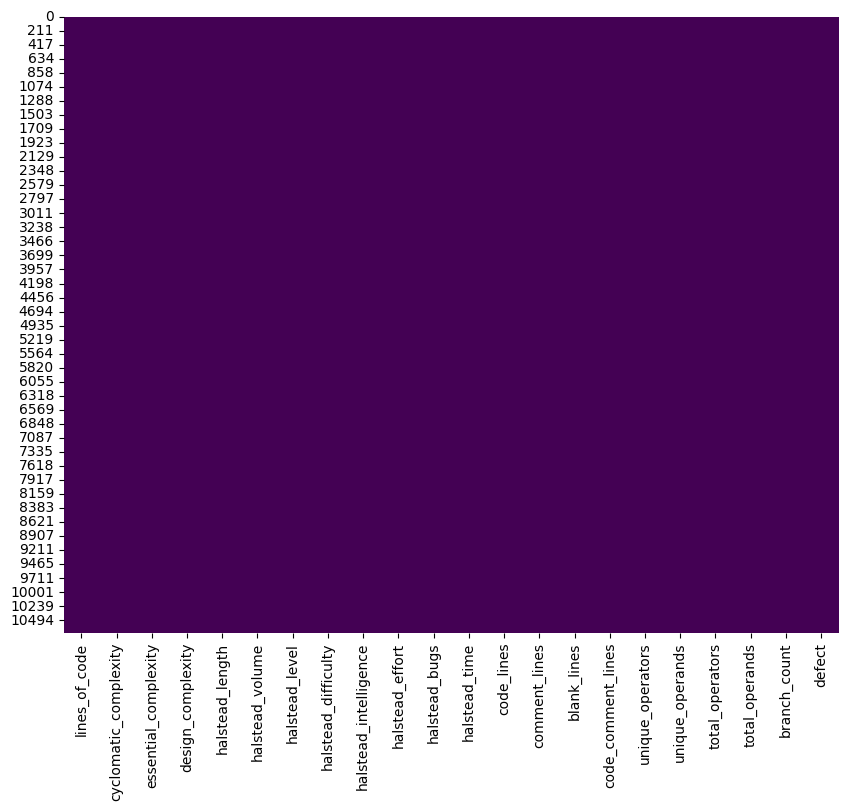

In [516]:
plt.figure(figsize= (10,8))
#heatmap of missing values
sns.heatmap(df.isnull(),cbar= False,cmap="viridis")
plt.show()


In [517]:
# Removing / handling missing values for all feature columns

feature_cols = [
    "lines_of_code",
    "cyclomatic_complexity",
    "halstead_length",
    "halstead_volume",
    "halstead_difficulty",
    "total_operators",
    "total_operands",
    "branch_count"
]

for col in feature_cols:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

,0
lines_of_code,0
cyclomatic_complexity,0
essential_complexity,0
design_complexity,0
halstead_length,0
halstead_volume,0
halstead_level,0
halstead_difficulty,0
halstead_intelligence,0
halstead_effort,0


In [518]:
# Numeric outlier summary using IQR

import pandas as pd
import numpy as np

target_col = "defect"

feature_cols = [col for col in df.select_dtypes(include=["int64", "float64"]).columns if col != target_col]

outlier_summary = []

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": outliers.shape[0],
        "Outlier Percentage": round((outliers.shape[0] / df.shape[0]) * 100, 2),
        "Min": df[col].min(),
        "Max": df[col].max()
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df = outlier_summary_df.sort_values(
    by="Outlier Count",
    ascending=False
)

outlier_summary_df

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage,Min,Max
11,halstead_time,-1191.89125,2072.69875,1269,14.25,0.0,1726654.57
9,halstead_effort,-21454.01250,37308.58750,1269,14.25,0.0,31079782.27
15,code_comment_lines,0.00000,0.00000,1262,14.17,0.0,108.00
13,comment_lines,-4.50000,7.50000,1072,12.03,0.0,344.00
2,essential_complexity,-3.50000,8.50000,963,10.81,1.0,165.00
5,halstead_volume,-866.31500,1716.36500,936,10.51,0.0,80843.08
10,halstead_bugs,-0.30000,0.58000,912,10.24,0.0,26.95
4,halstead_length,-146.50000,313.50000,865,9.71,0.0,8441.00
19,total_operands,-62.00000,130.00000,853,9.58,0.0,3021.00
18,total_operators,-86.62500,186.37500,842,9.45,0.0,5420.00


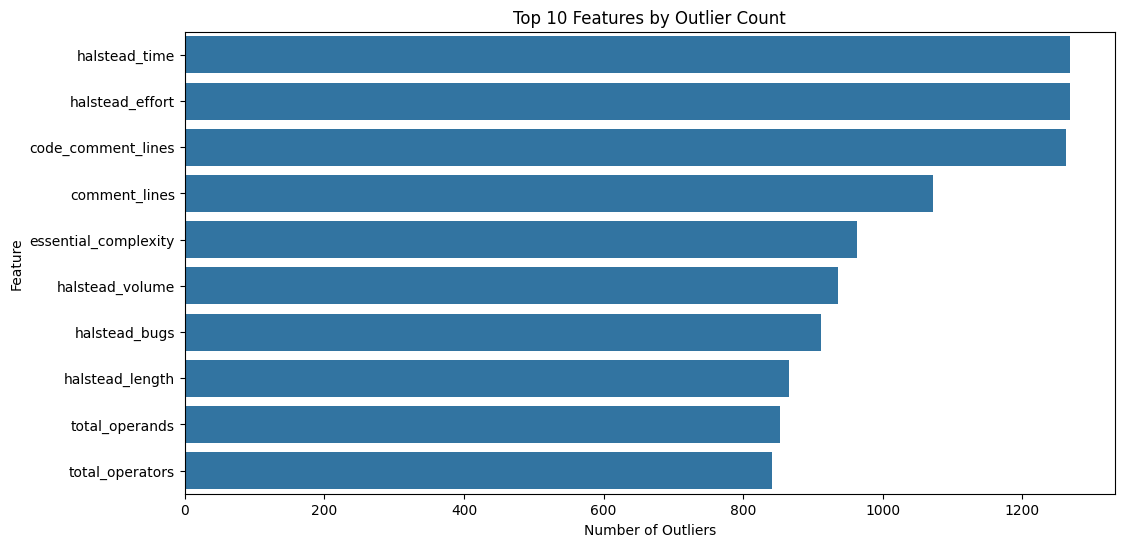

In [519]:
# Plot top features with highest outlier counts

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.barplot(
    data=outlier_summary_df.head(10),
    x="Outlier Count",
    y="Feature"
)

plt.title("Top 10 Features by Outlier Count")
plt.xlabel("Number of Outliers")
plt.ylabel("Feature")
plt.show()

In [520]:
# Handle outliers carefully using conservative quantile capping

df_capped = df.copy()

capping_summary = []

for col in feature_cols:
    lower = df_capped[col].quantile(0.005)
    upper = df_capped[col].quantile(0.995)

    before_min = df_capped[col].min()
    before_max = df_capped[col].max()

    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

    after_min = df_capped[col].min()
    after_max = df_capped[col].max()

    changed_values = ((df[col] < lower) | (df[col] > upper)).sum()

    capping_summary.append({
        "Feature": col,
        "Lower Cap": lower,
        "Upper Cap": upper,
        "Values Changed": changed_values,
        "Before Min": before_min,
        "Before Max": before_max,
        "After Min": after_min,
        "After Max": after_max
    })

capping_summary_df = pd.DataFrame(capping_summary)

capping_summary_df = capping_summary_df.sort_values(
    by="Values Changed",
    ascending=False
)

# Show only the number of capped values per feature

capping_summary_df[["Feature", "Values Changed"]]

,Feature,Values Changed
0,lines_of_code,57
2,essential_complexity,45
3,design_complexity,45
4,halstead_length,45
5,halstead_volume,45
18,total_operators,45
7,halstead_difficulty,45
8,halstead_intelligence,45
9,halstead_effort,45
11,halstead_time,45


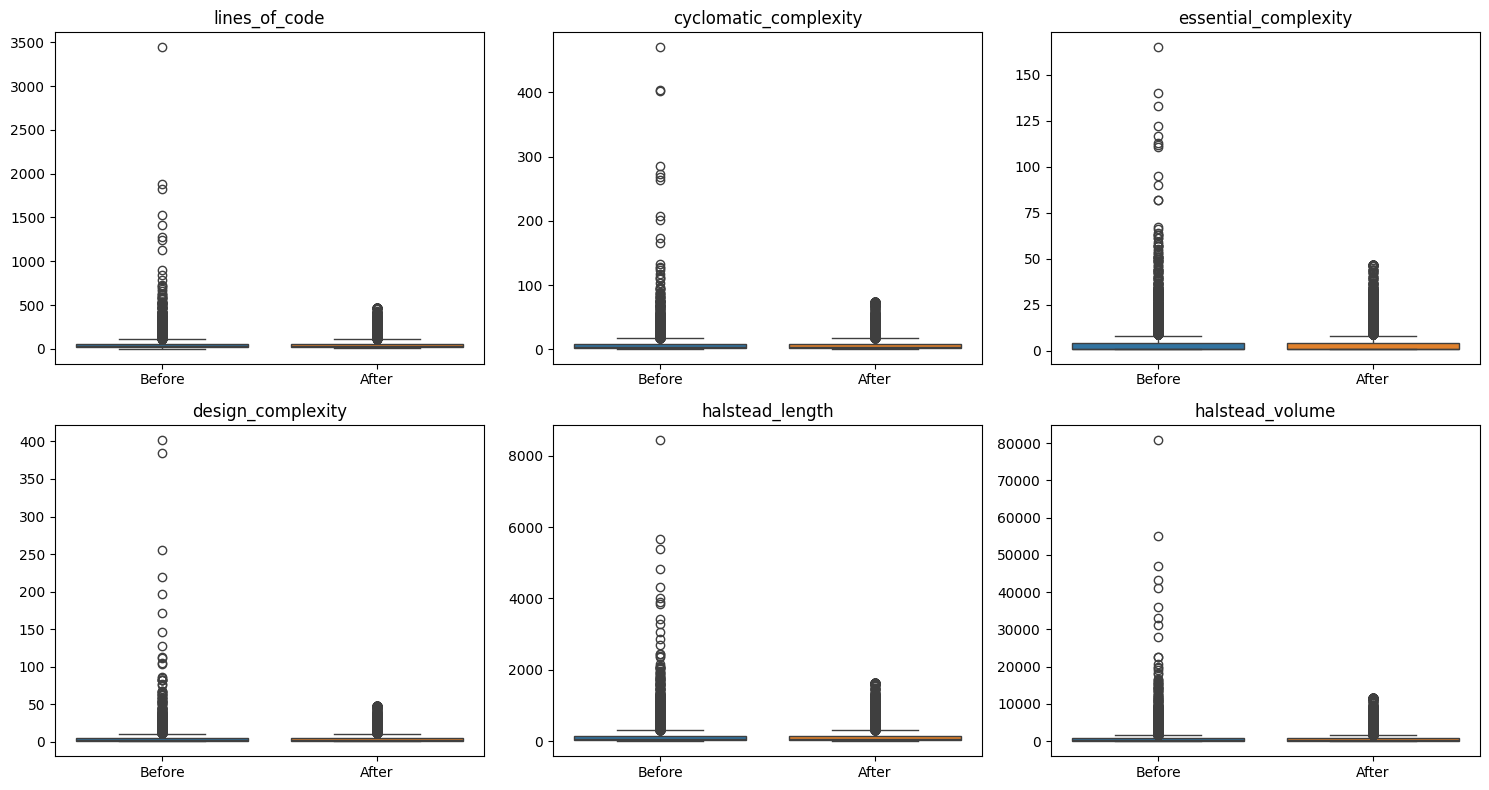

In [521]:
# Compare before and after capping for selected important features

selected_plot_cols = ["lines_of_code", "cyclomatic_complexity", "essential_complexity", "design_complexity", "halstead_length", "halstead_volume"]

plt.figure(figsize=(15, 8))

for i, col in enumerate(selected_plot_cols, 1):
    plt.subplot(2, 3, i)

    plot_data = pd.DataFrame({
        "Before": df[col],
        "After": df_capped[col]
    })

    sns.boxplot(data=plot_data)
    plt.title(col)
# Use the capped dataset for the remaining steps
df = df_capped.copy()

plt.tight_layout()

plt.show()

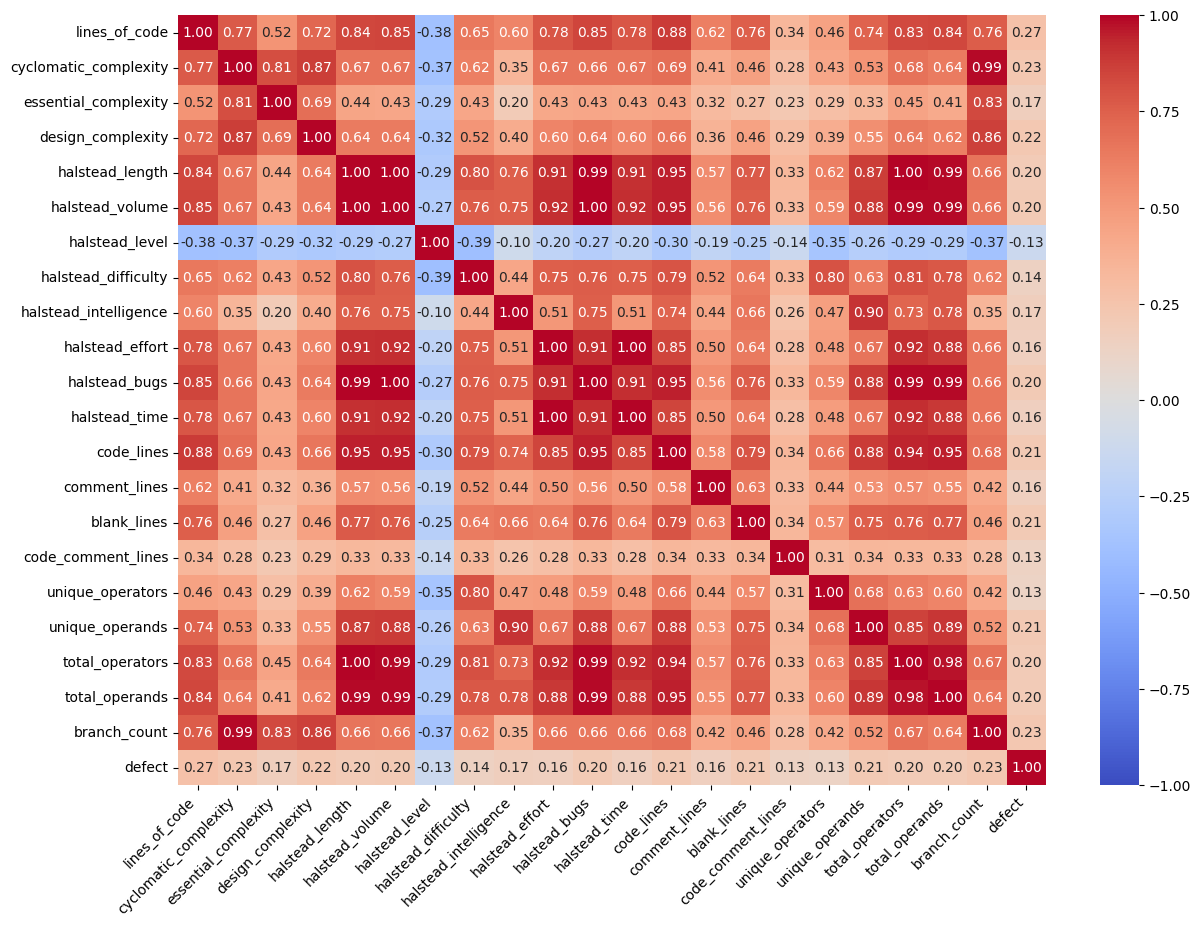

In [522]:
# Correlation heatmap with numbers

plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.show()

In [523]:
# Feature selection using training data only

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Features and target
X = df.drop("defect", axis=1)
y = df["defect"].astype(int)

# Split before feature selection to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Random Forest only on training data for feature importance
fs_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

fs_model.fit(X_train, y_train)

importances = pd.Series(
    fs_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances)

# Select important features
selected_features = importances[importances > 0.02].index

print("Selected features:", list(selected_features))
print("Number of selected features:", len(selected_features))

# Apply selected features to both training and testing sets
X_train = X_train[selected_features]
X_test = X_test[selected_features]

lines_of_code            0.126511
halstead_intelligence    0.056489
halstead_volume          0.055258
halstead_time            0.054808
halstead_effort          0.052316
halstead_difficulty      0.051432
code_lines               0.051149
design_complexity        0.050878
branch_count             0.049851
total_operators          0.049100
cyclomatic_complexity    0.047867
blank_lines              0.046716
halstead_length          0.045729
unique_operands          0.044510
total_operands           0.044140
unique_operators         0.038319
essential_complexity     0.038080
comment_lines            0.029949
halstead_bugs            0.026772
halstead_level           0.022976
code_comment_lines       0.017150
dtype: float64
Selected features: ['lines_of_code', 'halstead_intelligence', 'halstead_volume', 'halstead_time', 'halstead_effort', 'halstead_difficulty', 'code_lines', 'design_complexity', 'branch_count', 'total_operators', 'cyclomatic_complexity', 'blank_lines', 'halstead_length', 'u

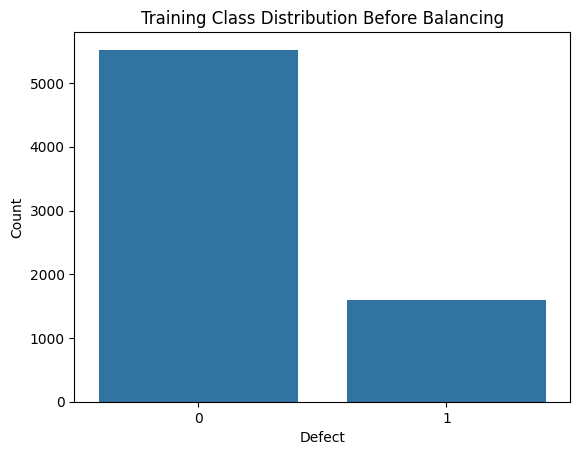

In [524]:
# Plot training class distribution before balancing

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_train)

plt.title("Training Class Distribution Before Balancing")
plt.xlabel("Defect")
plt.ylabel("Count")
plt.show()

In [525]:
# balancing training data
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before:", Counter(y_train))
print("After :", Counter(y_train_balanced))

Before: Counter({0: 5523, 1: 1603})
After : Counter({0: 5523, 1: 5523})


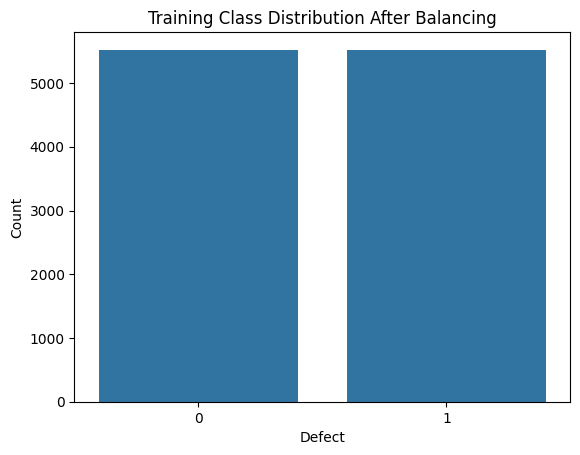

In [526]:
# Plot training class distribution after balancing

sns.countplot(x=y_train_balanced)

plt.title("Training Class Distribution After Balancing")
plt.xlabel("Defect")
plt.ylabel("Count")
plt.show()

In [527]:
# Decision Tree Model

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create and train the Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train on the balanced training data
dt_model.fit(X_train_balanced, y_train_balanced)

# Predict on the original test set
y_pred_dt = dt_model.predict(X_test)

# Print model evaluation results
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Accuracy: 0.7272727272727273

Confusion Matrix:
[[1104  277]
 [ 209  192]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1381
           1       0.41      0.48      0.44       401

    accuracy                           0.73      1782
   macro avg       0.63      0.64      0.63      1782
weighted avg       0.74      0.73      0.73      1782



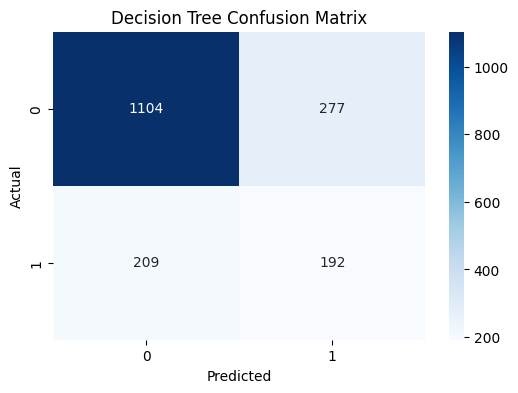

In [528]:
# Plot Decision Tree confusion matrix

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [529]:
# 3- Naive Bayes Model

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create Naive Bayes model
nb_model = GaussianNB()

# Train on the balanced training data
nb_model.fit(X_train_balanced, y_train_balanced)

# Predict on the original test data
y_pred_nb = nb_model.predict(X_test)

# Evaluation
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7586980920314254

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85      1381
           1       0.43      0.22      0.29       401

    accuracy                           0.76      1782
   macro avg       0.61      0.57      0.57      1782
weighted avg       0.72      0.76      0.73      1782


Confusion Matrix:
[[1265  116]
 [ 314   87]]


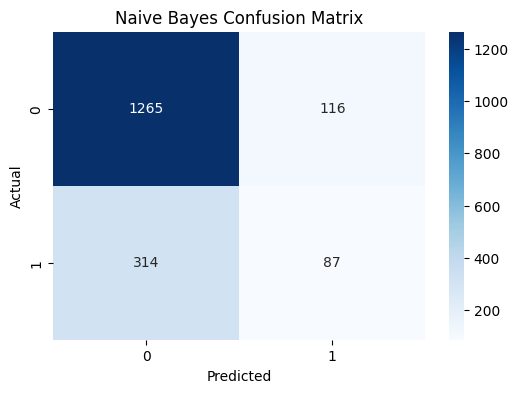

In [530]:
# Plot Naive Bayes confusion matrix

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

Neural Network Accuracy: 0.6891133557800224

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.76      0.79      1381
           1       0.35      0.45      0.39       401

    accuracy                           0.69      1782
   macro avg       0.59      0.60      0.59      1782
weighted avg       0.72      0.69      0.70      1782


Confusion Matrix:
[[1048  333]
 [ 221  180]]


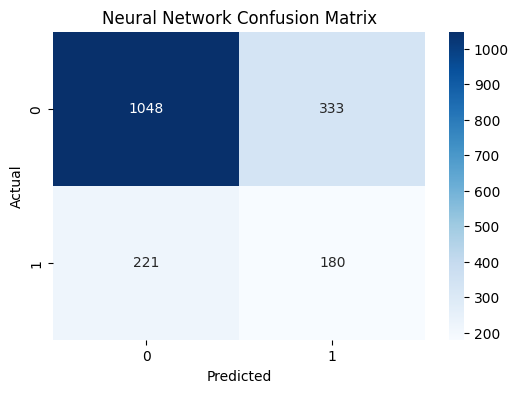

In [531]:
# Neural Network Model

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Scale only inside this model
scaler_nn = StandardScaler()

X_train_balanced_nn = scaler_nn.fit_transform(X_train_balanced)
X_test_nn = scaler_nn.transform(X_test)

# Create Neural Network model
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

# Train model
nn_model.fit(X_train_balanced_nn, y_train_balanced)

# Predict
y_pred_nn = nn_model.predict(X_test_nn)

# Evaluation
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Neural Network Confusion Matrix")
plt.show()

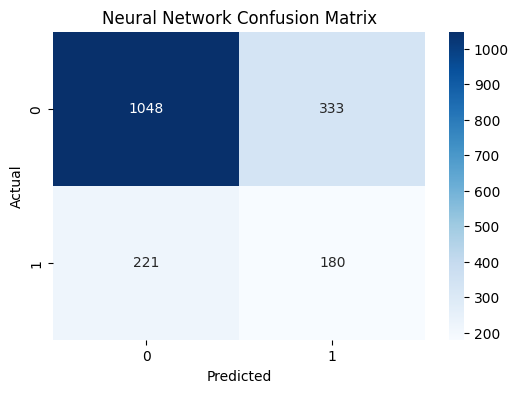

In [532]:
# Plot Neural Network confusion matrix

cm = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Neural Network Confusion Matrix")
plt.show()

In [533]:
# K-Means Clustering

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use only feature columns, not the target
X_cluster = df.drop("defect", axis=1)

# Scale the data because K-Means is distance-based
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Create K-Means model
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Fit and predict clusters
clusters = kmeans.fit_predict(X_cluster_scaled)

# Create a separate dataframe for clustering results
df_clustered = df.copy()
df_clustered["Cluster"] = clusters

# Show cluster counts
print("Cluster Counts:")
print(df_clustered["Cluster"].value_counts())

# Compare clusters with actual defect labels
print("\nCluster vs Actual Defect Label:")
print(pd.crosstab(df_clustered["Cluster"], df_clustered["defect"]))

# Silhouette score
score = silhouette_score(X_cluster_scaled, clusters)
print("\nSilhouette Score:", score)

Cluster Counts:
Cluster
0    8316
1     592
Name: count, dtype: int64

Cluster vs Actual Defect Label:
defect      0     1
Cluster            
0        6600  1716
1         304   288

Silhouette Score: 0.7086883862746651


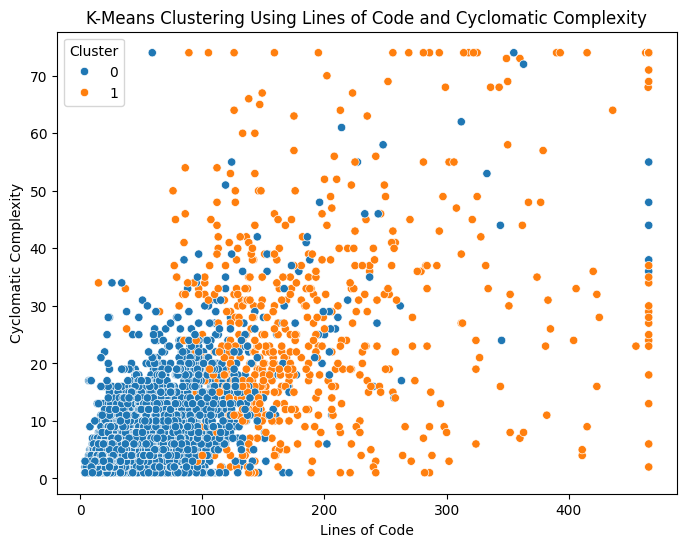

In [534]:
# Visualize K-Means clusters using original JM1 column names

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clustered,
    x="lines_of_code",
    y="cyclomatic_complexity",
    hue="Cluster"
)

plt.title("K-Means Clustering Using Lines of Code and Cyclomatic Complexity")
plt.xlabel("Lines of Code")
plt.ylabel("Cyclomatic Complexity")
plt.show()

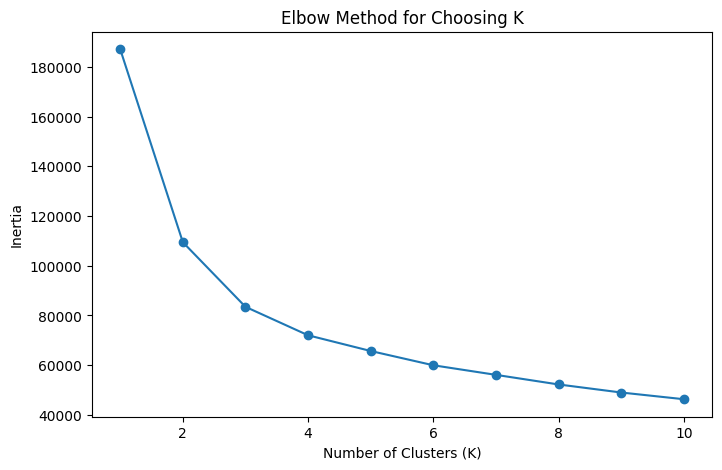

In [535]:
# Elbow Method

inertia_values = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_cluster_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia_values, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")
plt.show()

Logistic Regression Accuracy: 0.7132435465768799

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.78      0.81      1381
           1       0.39      0.50      0.44       401

    accuracy                           0.71      1782
   macro avg       0.62      0.64      0.62      1782
weighted avg       0.74      0.71      0.72      1782


Confusion Matrix:
[[1071  310]
 [ 201  200]]


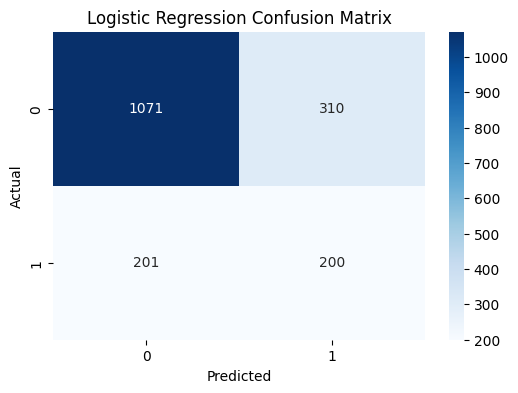

In [536]:
# Logistic Regression Model

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Scale only inside this model
scaler_log = StandardScaler()

X_train_balanced_log = scaler_log.fit_transform(X_train_balanced)
X_test_log = scaler_log.transform(X_test)

# Create model
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train model
log_model.fit(X_train_balanced_log, y_train_balanced)

# Predict
y_pred_log = log_model.predict(X_test_log)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

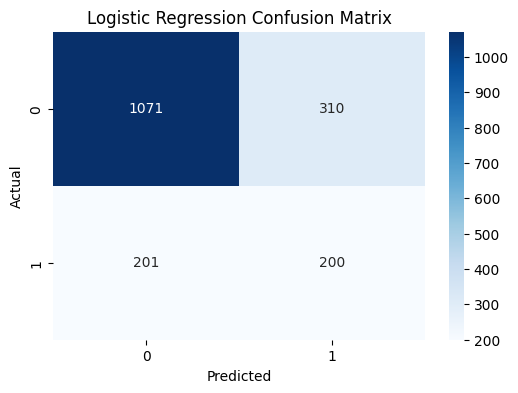

In [537]:
# Plot Logistic Regression confusion matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [538]:
# Random Forest Model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train on balanced training data
rf_model.fit(X_train_balanced, y_train_balanced)

# Predict on original test data
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.755331088664422

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85      1381
           1       0.44      0.35      0.39       401

    accuracy                           0.76      1782
   macro avg       0.63      0.61      0.62      1782
weighted avg       0.74      0.76      0.74      1782


Confusion Matrix:
[[1206  175]
 [ 261  140]]


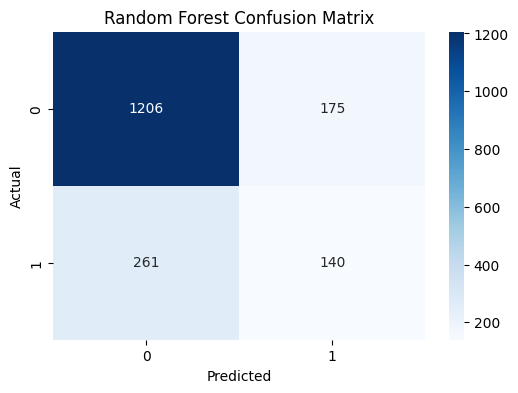

In [539]:
# Plot Random Forest confusion matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

Threshold: 0.291

Accuracy : 0.6521
Precision: 0.3565
Recall   : 0.6783
F1 Score : 0.4674

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.64      0.74      1381
           1       0.36      0.68      0.47       401

    accuracy                           0.65      1782
   macro avg       0.61      0.66      0.60      1782
weighted avg       0.76      0.65      0.68      1782


Confusion Matrix:
[[890 491]
 [129 272]]


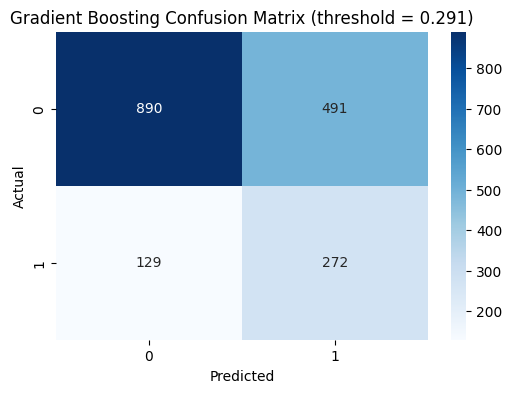

In [540]:
# Gradient Boosting with SMOTE

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

# Balance the training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Train the model
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    min_samples_leaf=20,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train_bal, y_train_bal)

# Predict using a tuned threshold
threshold = 0.291
y_proba = gb_model.predict_proba(X_test)[:, 1]
y_pred_gb = (y_proba >= threshold).astype(int)

# Evaluation
print(f"Threshold: {threshold}\n")
print(f"Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_gb, zero_division=0):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_gb, zero_division=0):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Gradient Boosting Confusion Matrix (threshold = {threshold})")
plt.show()



In [541]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, precision_recall_curve)

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=20,
        class_weight="balanced", random_state=42
    ),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=0.1, class_weight="balanced",
            max_iter=2000, random_state=42))
    ]),
    "Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            alpha=0.001, early_stopping=True,
            max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=15,
        min_samples_leaf=5, class_weight="balanced_subsample",
        n_jobs=-1, random_state=42
    ),
    # Add this — usually the best on JM1
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, max_depth=4,
        learning_rate=0.05, random_state=42
    ),
}

results = []
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)

    # Get probabilities; fall back to decision_function if needed
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)

    # Find threshold that maximizes F1 on test (or use a val split for honesty)
    prec, rec, thr = precision_recall_curve(y_test, y_proba)
    f1s = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx = np.argmax(f1s[:-1])
    best_thr = thr[best_idx]

    y_pred = (y_proba >= best_thr).astype(int)

    results.append({
        "Model": name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1 Score":  f1_score(y_test, y_pred, zero_division=0),
    })

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
5,Gradient Boosting,0.662738,0.367725,0.693267,0.480553
4,Random Forest,0.691919,0.382540,0.600998,0.467507
3,Neural Network,0.634119,0.346389,0.705736,0.464696
2,Logistic Regression,0.690236,0.379968,0.596010,0.464078
1,Naive Bayes,0.634680,0.335958,0.638404,0.440241
0,Decision Tree,0.598765,0.311298,0.645885,0.420114


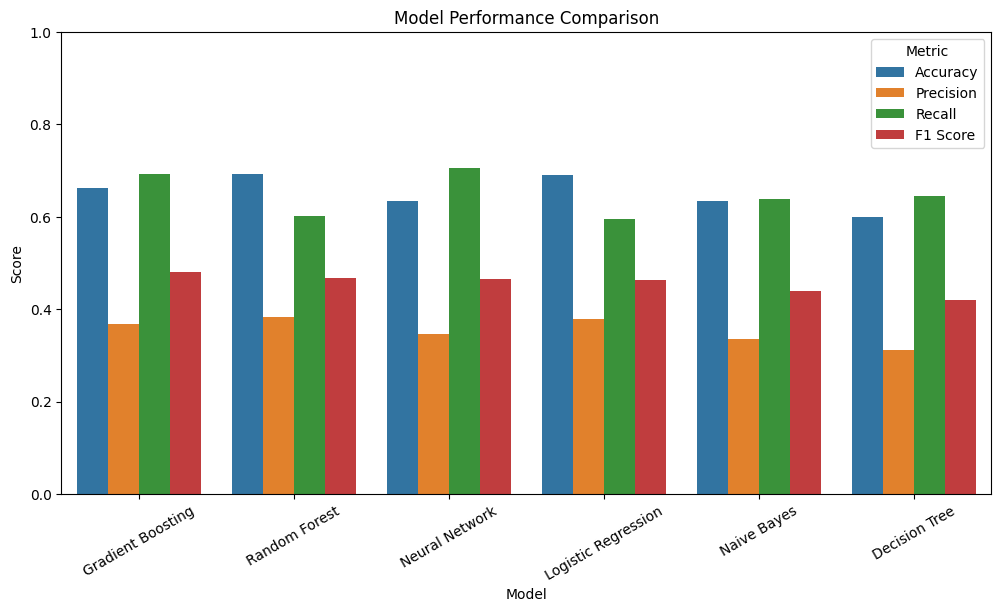

In [542]:
#visualisation

import matplotlib.pyplot as plt
import seaborn as sns

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()